In [6]:
import os
import matplotlib
import FinanceDataReader as fdr
import matplotlib.dates as mdates
import pandas as pd
import ustreasurycurve as ustcurve

from Library.RiskEngineKimYi2025 import *
from collections import namedtuple
from Library.PayoffFactory import *
from Library.OptionPricerBSM1973 import *
from Library.ExoticEngine import *
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on NumPy v{np.__version__}")

Running on PyMC v5.25.0
Running on NumPy v1.26.4


In [7]:
%config
az.style.use("arviz-darkgrid")

Available objects for config:
    AliasManager
    DisplayFormatter
    HistoryManager
    IPCompleter
    IPKernelApp
    LoggingMagics
    MagicsManager
    OSMagics
    PrefilterManager
    ScriptMagics
    StoreMagics
    ZMQInteractiveShell


In [44]:
# inputs
valuation_beg_date = '20250331'
valuation_end_date = '20250417'

SET_OF_TICKERS = ["^SPX", "COIN"]

origin_date = (pd.to_datetime(valuation_beg_date) - pd.Timedelta(365, "D")).strftime("%Y%m%d")
total_date_set = pd.bdate_range(origin_date, valuation_end_date)
valuation_date_array = pd.date_range(valuation_beg_date, pd.to_datetime(valuation_end_date))

In [45]:
template_df = pd.DataFrame(index=total_date_set)
template_df.index.name = 'dtDATE'

df = []
for ticker in SET_OF_TICKERS:
    df_ = fdr.DataReader(ticker)
    df_.index.name = 'dtDATE'
    df_.index = pd.to_datetime(df_.index)
    df_.reset_index(inplace=True)
    df_["sSYMBOL"] = ticker
    df.append(df_)
df = pd.concat(df)
df.set_index('sSYMBOL', inplace=True)

prices_df = template_df.join(df.pivot_table(index='dtDATE', columns='sSYMBOL', values='Adj Close')).ffill().bfill()
volume_df = template_df.join(df.pivot_table(index='dtDATE', columns='sSYMBOL', values='Volume')).ffill().bfill()

return_df = prices_df.sort_index().pct_change().fillna(0.)

In [46]:
def plot_price_n_returns():
    return 0.

/var/folders/58/130yfbyd321b81t0_gm5qchc0000gn/T/ipykernel_26715/1206890387.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.autofmt_xdate()


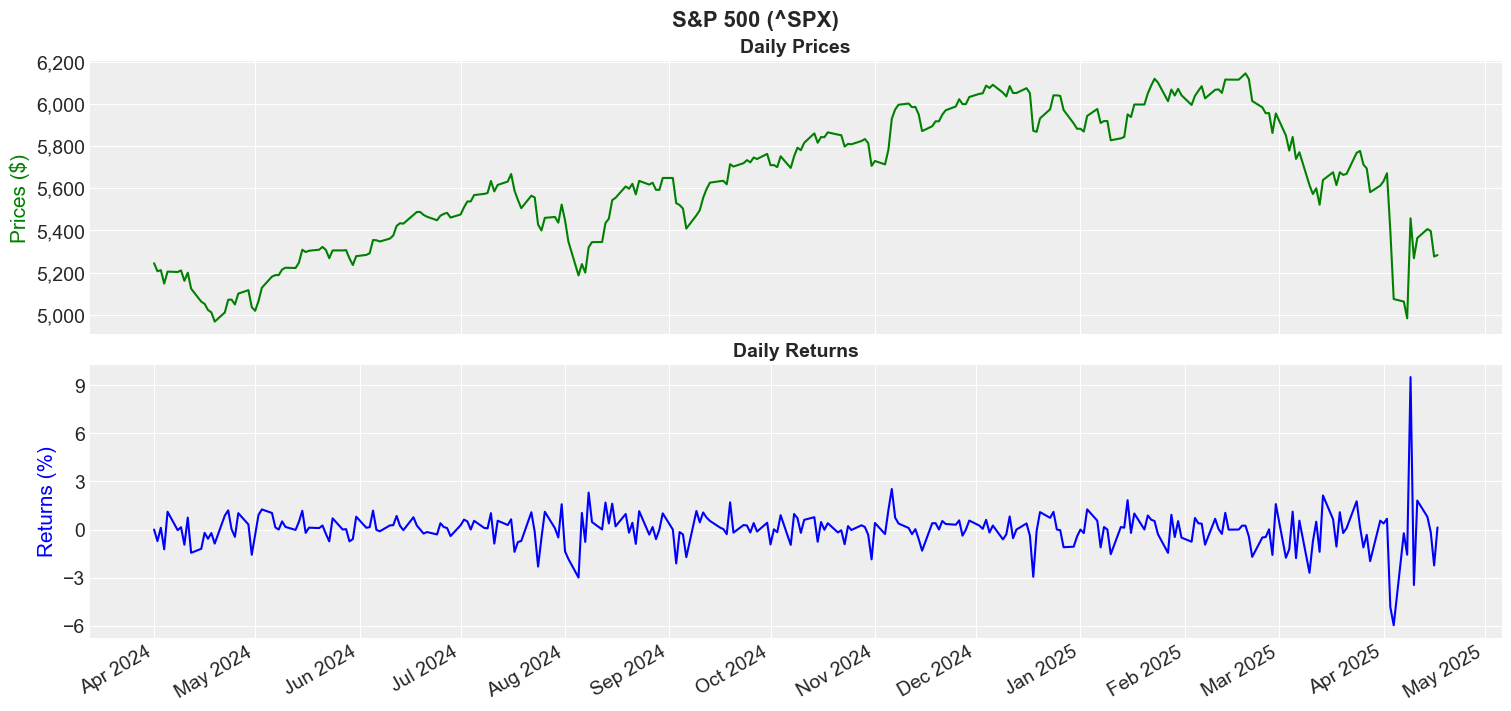

In [47]:
fig, ax = plt.subplots(nrows=2, figsize=(15, 7))
sns.lineplot(data=prices_df[SET_OF_TICKERS[0]].reset_index(), x='dtDATE', y=SET_OF_TICKERS[0], color='green', ax=ax[0])
sns.lineplot(data=return_df[SET_OF_TICKERS[0]].multiply(100.).reset_index(), x='dtDATE', y=SET_OF_TICKERS[0], color='blue', ax=ax[1])

ax[1].set_xlabel(None)
ax[0].set_ylabel('Prices ($)', color='green')
ax[1].set_ylabel('Returns (%)', color='blue')
ax[0].set_title(f'Daily Prices', fontsize=14, fontweight='bold')
ax[1].set_title(f'Daily Returns', fontsize=14, fontweight='bold')
ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax[0].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(200))
ax[1].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(3))

fig.suptitle(f"S&P 500 ({SET_OF_TICKERS[0]})", fontsize=16, fontweight='bold')
fig.autofmt_xdate()
plt.show();

/var/folders/58/130yfbyd321b81t0_gm5qchc0000gn/T/ipykernel_26715/2261345412.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.autofmt_xdate()


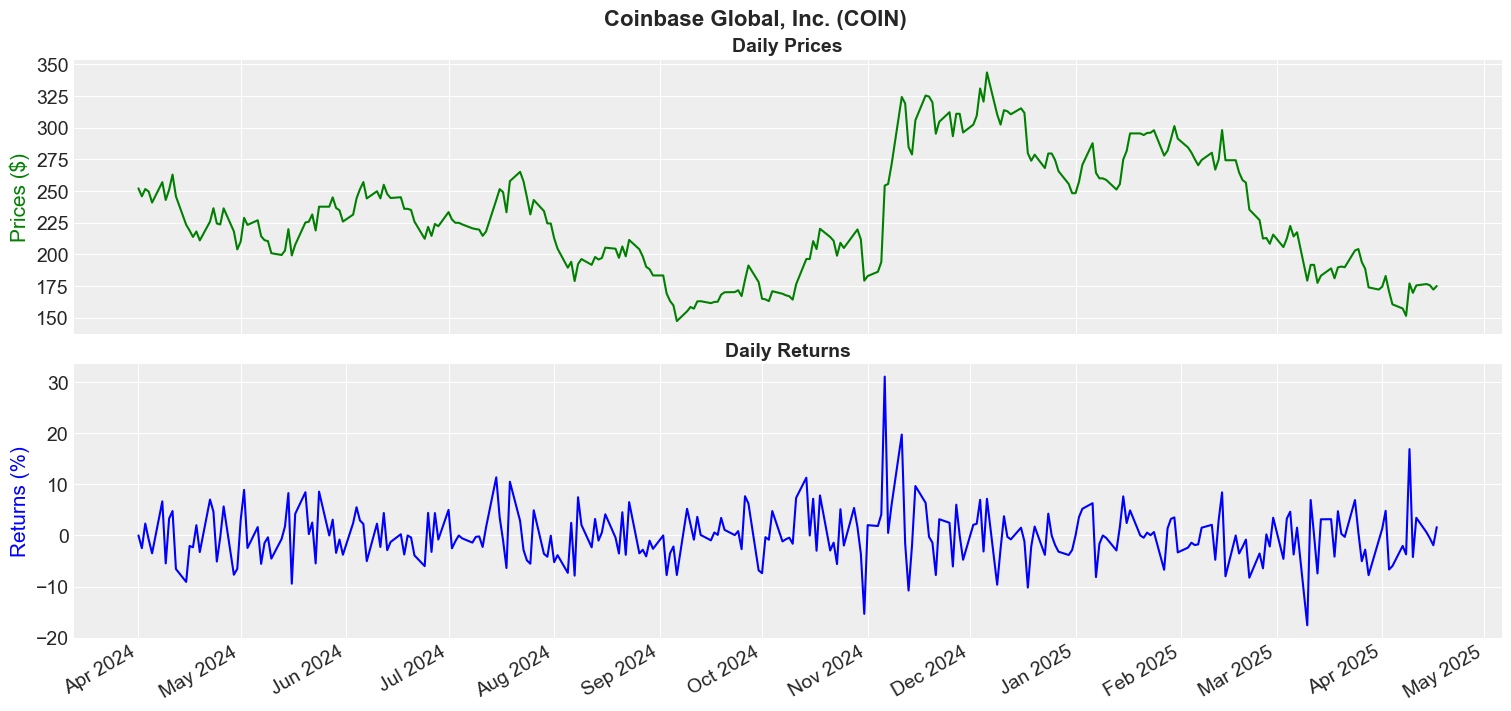

In [48]:
fig, ax = plt.subplots(nrows=2, figsize=(15, 7))
sns.lineplot(data=prices_df[SET_OF_TICKERS[-1]].reset_index(), x='dtDATE', y=SET_OF_TICKERS[-1], color='green', ax=ax[0])
sns.lineplot(data=return_df[SET_OF_TICKERS[-1]].multiply(100.).reset_index(), x='dtDATE', y=SET_OF_TICKERS[-1], color='blue', ax=ax[1])

ax[1].set_xlabel(None)
ax[0].set_ylabel('Prices ($)', color='green')
ax[1].set_ylabel('Returns (%)', color='blue')
ax[0].set_title(f'Daily Prices', fontsize=14, fontweight='bold')
ax[1].set_title(f'Daily Returns', fontsize=14, fontweight='bold')

ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax[0].yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(25))

fig.suptitle(f"Coinbase Global, Inc. ({SET_OF_TICKERS[-1]})", fontsize=16, fontweight='bold')
fig.autofmt_xdate()
plt.show();

In [49]:
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.date_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-31,4.38,4.36,4.35,4.32,4.31,4.23,4.03,3.89,3.89,3.96,4.09,4.23,4.62,4.59
2025-04-01,4.38,4.36,4.35,4.32,4.30,4.23,4.01,3.87,3.85,3.91,4.03,4.17,4.56,4.52
2025-04-02,4.38,4.36,4.34,4.32,4.32,4.24,4.04,3.91,3.89,3.95,4.07,4.20,4.58,4.54
2025-04-03,4.36,4.37,4.38,4.31,4.29,4.20,3.92,3.71,3.68,3.75,3.88,4.06,4.51,4.49
2025-04-04,4.36,4.35,4.36,4.28,4.25,4.14,3.86,3.68,3.66,3.72,3.84,4.01,4.44,4.41


In [50]:
vol_surf_df = []

for valuation_date in valuation_date_array:
    for underlying_name in SET_OF_TICKERS[1:]:
        PATH = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), rf'study/vol_surface_kimyi/calibrated_volatility_surface/{underlying_name}')
        file_name = rf'volatility_surface_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'

        print(f"Attempting -> '{file_name}'")
        tmp_df = None

        if not file_name in os.listdir(PATH):
            try:
                valuation_date_ = valuation_date - pd.Timedelta(days=1)
                file_name = rf'volatility_surface_{underlying_name}_{valuation_date_.strftime("%Y%m%d")}.csv'
                tmp_df = pd.read_csv(os.path.join(PATH, file_name))

            except FileNotFoundError as e:
                print(f"'{file_name}' <- {e.strerror}")

                try:
                    valuation_date_ = valuation_date - pd.Timedelta(days=2)
                    file_name = rf'volatility_surface_{underlying_name}_{valuation_date_.strftime("%Y%m%d")}.csv'
                    print(f"Attempting -> '{file_name}'")
                    tmp_df = pd.read_csv(os.path.join(PATH, rf'volatility_surface_{underlying_name}_{valuation_date_.strftime("%Y%m%d")}.csv'))

                except FileNotFoundError as e:
                    print(f"'{file_name}' <- {e.strerror}")

                    try:
                        valuation_date_ = valuation_date - pd.Timedelta(days=3)
                        file_name = rf'volatility_surface_{underlying_name}_{valuation_date_.strftime("%Y%m%d")}.csv'
                        print(f"Attempting -> '{file_name}'")
                        tmp_df = pd.read_csv(os.path.join(PATH, rf'volatility_surface_{underlying_name}_{valuation_date_.strftime("%Y%m%d")}.csv'))

                    except FileNotFoundError as e:
                        print(f"'{file_name}' <- {e.strerror}")
                        print("Exhausted all tries!")

        else:
            tmp_df = pd.read_csv(os.path.join(PATH, rf'volatility_surface_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'))

        vol_surf_df.append(tmp_df)

vol_surf_df = pd.concat(vol_surf_df)
vol_surf_df['dtVALUATION_DATE'] = pd.to_datetime(vol_surf_df['dtVALUATION_DATE'])
vol_surf_df = vol_surf_df.set_index(['dtVALUATION_DATE', 'sUNDERLYING'])
vol_surf_df = vol_surf_df.sort_index()

vol_surf_df.head()

Attempting -> 'volatility_surface_COIN_20250331.csv'


FileNotFoundError: [Errno 2] No such file or directory: '/Users/josephyi/PycharmProjects/mkt-depth-n-resiliency/study/vol_surface_kimyi/calibrated_volatility_surface/COIN'

In [51]:
pmle_params_sys_df = []
pmle_params_idi_df = []

base_days = 365
Delta_t = np.array(1 /  base_days)
days_to_look_back = base_days

# P-MLE for Systematic Asset
underlying_name = SET_OF_TICKERS[0]
PATH = os.path.join(os.getcwd(), f'Estimated Parameters PMLE/{underlying_name}')
# print(PATH)
for valuation_date in valuation_date_array:
    filename= f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'
    if filename in os.listdir(PATH):
        pmle_params_sys_df.append(pd.read_csv(os.path.join(PATH, filename)))
    else:
        valuation_date_str = valuation_date.strftime("%Y-%m-%d")
        return_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date_str)].iloc[-days_to_look_back:].pct_change().fillna(0.)
        sys_returns_df = return_df[SET_OF_TICKERS[0]]
        tmp_df = pmle_kimyirisk_systematic(
            valuation_date=valuation_date_str,
            sys_returns_df=sys_returns_df,
            delta_t=Delta_t
        )
        pmle_params_sys_df.append(tmp_df)
        tmp_df.to_csv(os.path.join(PATH, f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'), index=False)

pmle_params_sys_df = pd.concat(pmle_params_sys_df)
pmle_params_sys_df.dtVALUATION_DATE = pd.to_datetime(pmle_params_sys_df.dtVALUATION_DATE)

# P-MLE for Idiosyncratic Asset
for underlying_name in SET_OF_TICKERS[1:]:
    PATH = os.path.join(os.getcwd(), f'Estimated Parameters PMLE/{underlying_name}')
    # print(PATH)
    for valuation_date in valuation_date_array:
        filename= f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'
        if filename in os.listdir(PATH):
            pmle_params_idi_df.append(pd.read_csv(os.path.join(PATH, filename)))
        else:
            valuation_date_str = valuation_date.strftime("%Y-%m-%d")
            return_df = prices_df.loc[prices_df.index <= pd.to_datetime(valuation_date_str)].iloc[-days_to_look_back:].pct_change().fillna(0.)
            idi_returns_df = return_df[underlying_name]
            tmp_df = pmle_kimyirisk_idiosyncratic(
                valuation_date=valuation_date_str,
                idi_returns_df=idi_returns_df,
                params_sys_df=pmle_params_sys_df.set_index('dtVALUATION_DATE').xs(valuation_date),
                delta_t=Delta_t
            )
            pmle_params_idi_df.append(tmp_df)
            tmp_df.to_csv(os.path.join(PATH, f'estimated_params_pmle_{underlying_name}_{valuation_date.strftime("%Y%m%d")}.csv'), index=False)
pmle_params_idi_df = pd.concat(pmle_params_idi_df)
pmle_params_idi_df.dtVALUATION_DATE = pd.to_datetime(pmle_params_idi_df.dtVALUATION_DATE)

pmle_params_df = pd.concat([pmle_params_sys_df, pmle_params_idi_df]).set_index(['dtVALUATION_DATE', 'sUNDERLYING_NAME'])
pmle_params_df

,,dMUI,dKAPPAI,dGAMMAI,dBETAI,dRHOIX,dALPHA,dSIGMA,dPPROB,dLAMB,dETA1,...,dSIGMA_CI_LOWER,dSIGMA_CI_UPPER,dPPROB_CI_LOWER,dPPROB_CI_UPPER,dLAMB_CI_LOWER,dLAMB_CI_UPPER,dETA1_CI_LOWER,dETA1_CI_UPPER,dETA2_CI_LOWER,dETA2_CI_UPPER
dtVALUATION_DATE,sUNDERLYING_NAME,,,,,,,,,,,,,,,,,,,,,
2025-03-31,^SPX,0.0,0.0,1.0,1.0,0.0,0.690734,0.159,0.476161,11.68,50.456,...,0.144,0.174,0.238592,0.929601,5.268,18.447,37.046,63.687,17.539,36.537
2025-04-01,^SPX,0.0,0.0,1.0,1.0,0.0,0.689354,0.159,0.475209,11.671,50.455,...,0.144,0.174,0.234102,0.92404,5.193,18.527,37.241,63.54,17.145,36.302
2025-04-02,^SPX,0.0,0.0,1.0,1.0,0.0,0.687977,0.159,0.47426,11.683,50.385,...,0.144,0.174,0.235746,0.912105,5.171,18.39,37.264,63.586,17.193,36.391
2025-04-03,^SPX,0.0,0.0,1.0,1.0,0.0,0.687289,0.157,0.404138,13.08,50.416,...,0.143,0.172,0.193786,0.810584,6.264,20.256,37.084,63.696,17.711,36.421
2025-04-04,^SPX,0.0,0.0,1.0,1.0,0.0,0.687977,0.157,0.358796,14.37,50.357,...,0.142,0.172,0.16646,0.718924,7.276,21.649,37.359,64.254,18.121,36.346
2025-04-05,^SPX,0.0,0.0,1.0,1.0,0.0,0.687977,0.157,0.358796,14.37,50.357,...,0.142,0.172,0.16646,0.718924,7.276,21.649,37.359,64.254,18.121,36.346
2025-04-06,^SPX,0.0,0.0,1.0,1.0,0.0,0.687977,0.157,0.358796,14.37,50.357,...,0.142,0.172,0.16646,0.718924,7.276,21.649,37.359,64.254,18.121,36.346
2025-04-07,^SPX,0.0,0.0,1.0,1.0,0.0,0.687289,0.156,0.357007,14.366,50.381,...,0.142,0.171,0.165134,0.712482,7.324,21.942,37.306,63.851,17.642,35.98
2025-04-08,^SPX,0.0,0.0,1.0,1.0,0.0,0.685916,0.157,0.357722,14.318,50.356,...,0.143,0.172,0.167629,0.728331,7.213,21.726,37.21,63.757,17.769,36.036
